<a href="https://colab.research.google.com/github/celiablanco/YSPLanguageComplexity2026/blob/divya-work/YSP_Task_FullBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deep-translator -q

import os
os.makedirs("source", exist_ok=True)
os.makedirs("translated", exist_ok=True)

os.rename("input.txt", "source/input.txt")  # adjust filename if yours is different

with open("source/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Loaded {len(text)} characters, {len(text.split())} words")

Loaded 134514 characters, 26590 words


In [ ]:
import re

def split_into_chunks(text, max_chars=4500):
    """Split text into chunks under max_chars, breaking at sentence boundaries
    so we don't cut words/sentences in half mid-translation."""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks = []
    current = ""

    for sentence in sentences:
        if len(current) + len(sentence) + 1 <= max_chars:
            current += (" " if current else "") + sentence
        else:
            if current:
                chunks.append(current)
            current = sentence

    if current:
        chunks.append(current)

    return chunks

chunks = split_into_chunks(text)
print(f"Split into {len(chunks)} chunks")
print(f"Chunk sizes: {[len(c) for c in chunks[:5]]}... (showing first 5)")

Split into 30 chunks
Chunk sizes: [4460, 4470, 4321, 4477, 4484]... (showing first 5)


In [ ]:
from deep_translator import GoogleTranslator
import time
import os

supported = GoogleTranslator().get_supported_languages(as_dict=True)

def translate_book(chunks, target_code):
    translated_chunks = []
    for chunk in chunks:
        result = GoogleTranslator(source='en', target=target_code).translate(chunk)
        translated_chunks.append(result)
        time.sleep(0.2)
    return " ".join(translated_chunks)

total = len(supported)
completed = 0
failed = []

for i, (name, code) in enumerate(supported.items(), start=1):
    out_path = f"translated/{code}.txt"

    # SKIP if already done - this is what makes it resumable
    if os.path.exists(out_path):
        print(f"[{i}/{total}] {name} -> already done, skipping")
        completed += 1
        continue

    try:
        if code == "en":
            full_translation = text
        else:
            full_translation = translate_book(chunks, code)

        with open(out_path, "w", encoding="utf-8") as f:
            f.write(full_translation)

        print(f"[{i}/{total}] {name} -> DONE")
        completed += 1

    except Exception as e:
        print(f"[{i}/{total}] {name} -> FAILED: {e}")
        failed.append(code)

    time.sleep(0.3)

print(f"\n=== Finished this run: {completed}/{total} completed, {len(failed)} failed ===")
if failed:
    print("Failed:", failed)

[1/133] afrikaans -> already done, skipping
[2/133] albanian -> already done, skipping
[3/133] amharic -> already done, skipping
[4/133] arabic -> already done, skipping
[5/133] armenian -> already done, skipping
[6/133] assamese -> already done, skipping
[7/133] aymara -> already done, skipping
[8/133] azerbaijani -> already done, skipping
[9/133] bambara -> already done, skipping
[10/133] basque -> already done, skipping
[11/133] belarusian -> already done, skipping
[12/133] bengali -> already done, skipping
[13/133] bhojpuri -> already done, skipping
[14/133] bosnian -> already done, skipping
[15/133] bulgarian -> already done, skipping
[16/133] catalan -> already done, skipping
[17/133] cebuano -> already done, skipping
[18/133] chichewa -> already done, skipping
[19/133] chinese (simplified) -> already done, skipping
[20/133] chinese (traditional) -> already done, skipping
[21/133] corsican -> already done, skipping
[22/133] croatian -> already done, skipping
[23/133] czech -> alr

In [ ]:
import os
import pandas as pd

TRANSLATED_DIR = "translated"

files = sorted([f for f in os.listdir(TRANSLATED_DIR) if f.endswith(".txt")])

print(f"Found {len(files)} translated files")

Found 133 translated files


In [ ]:
import re
from collections import Counter

def analyze_text(text):

    # Unicode characters (code points)
    character_count = len(text)

    # Ignore spaces for some analyses
    characters_no_space = [c for c in text if not c.isspace()]

    character_count_no_spaces = len(characters_no_space)

    # Unique characters
    unique_characters = len(set(characters_no_space))

    # Words
    words = text.split()
    word_count = len(words)

    # Sentences
    sentences = re.split(r'[.!?。！？]+', text)
    sentences = [s for s in sentences if s.strip()]
    sentence_count = len(sentences)

    avg_chars_per_word = (
        character_count_no_spaces / word_count
        if word_count else 0
    )

    avg_words_per_sentence = (
        word_count / sentence_count
        if sentence_count else 0
    )

    avg_chars_per_sentence = (
        character_count_no_spaces / sentence_count
        if sentence_count else 0
    )

    return {
        "Character Count": character_count,
        "Character Count (No Spaces)": character_count_no_spaces,
        "Unique Characters": unique_characters,
        "Word Count": word_count,
        "Sentence Count": sentence_count,
        "Characters / Word": avg_chars_per_word,
        "Words / Sentence": avg_words_per_sentence,
        "Characters / Sentence": avg_chars_per_sentence,
    }

In [ ]:
results = []

for file in files:

    language = file.replace(".txt","")

    with open(os.path.join(TRANSLATED_DIR,file),
              encoding="utf-8") as f:

        text = f.read()

    stats = analyze_text(text)

    stats["Language"] = language

    results.append(stats)

df = pd.DataFrame(results)

df = df.sort_values("Language")

df.head()

,Character Count,Character Count (No Spaces),Unique Characters,Word Count,Sentence Count,Characters / Word,Words / Sentence,Characters / Sentence,Language
0,135627,107729,70,27651,1924,3.896025,14.371622,55.992204,af
1,135710,106783,73,28680,2106,3.723257,13.618234,50.704179,ak
2,84231,65993,257,17991,878,3.668112,20.490888,75.162870,am
3,108615,88270,80,20098,1823,4.391979,11.024685,48.420187,ar
4,129967,107591,98,22129,280,4.861991,79.032143,384.253571,as


In [41]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(df)

,Character Count,Character Count (No Spaces),Unique Characters,Word Count,Sentence Count,Characters / Word,Words / Sentence,Characters / Sentence,Language
0,135627,107729,70,27651,1924,3.896025,14.371622,55.992204,af
1,135710,106783,73,28680,2106,3.723257,13.618234,50.704179,ak
2,84231,65993,257,17991,878,3.668112,20.490888,75.162870,am
3,108615,88270,80,20098,1823,4.391979,11.024685,48.420187,ar
4,129967,107591,98,22129,280,4.861991,79.032143,384.253571,as
5,162730,142309,77,20174,2047,7.054080,9.855398,69.520762,ay
6,124606,105198,80,19161,1930,5.490214,9.927979,54.506736,az
7,125376,103227,121,21902,1921,4.713131,11.401353,53.736075,be
8,131692,107728,103,23717,1913,4.542227,12.397804,56.313643,bg
9,130629,101267,86,29115,983,3.478173,29.618515,103.018311,bho


In [42]:
df.to_csv("character_statistics.csv", index=False)

print("Saved as character_statistics.csv")

Saved as character_statistics.csv


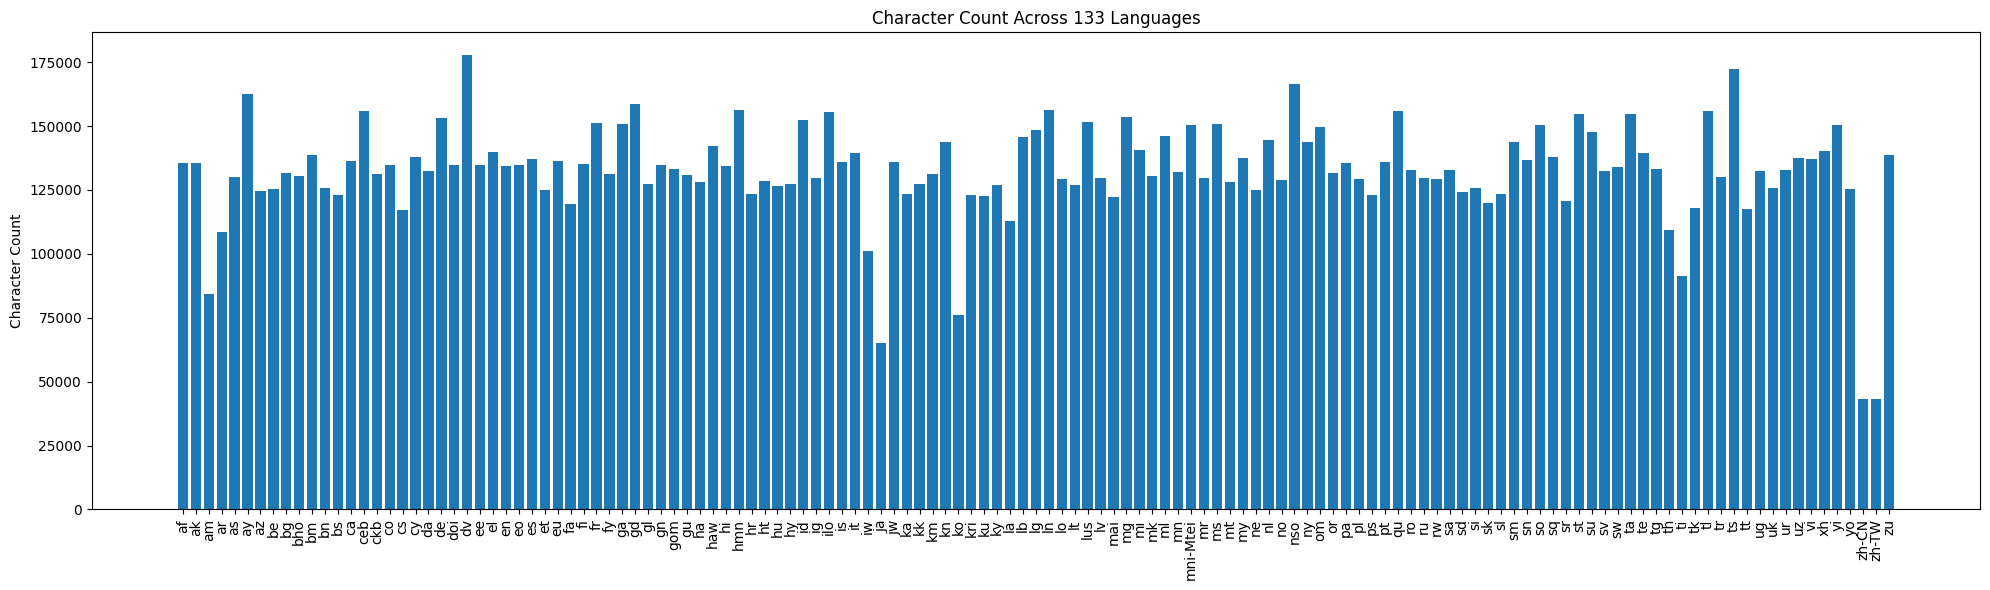

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))

plt.bar(df["Language"], df["Character Count"])

plt.xticks(rotation=90)

plt.ylabel("Character Count")

plt.title("Character Count Across 133 Languages")

plt.tight_layout()

plt.show()

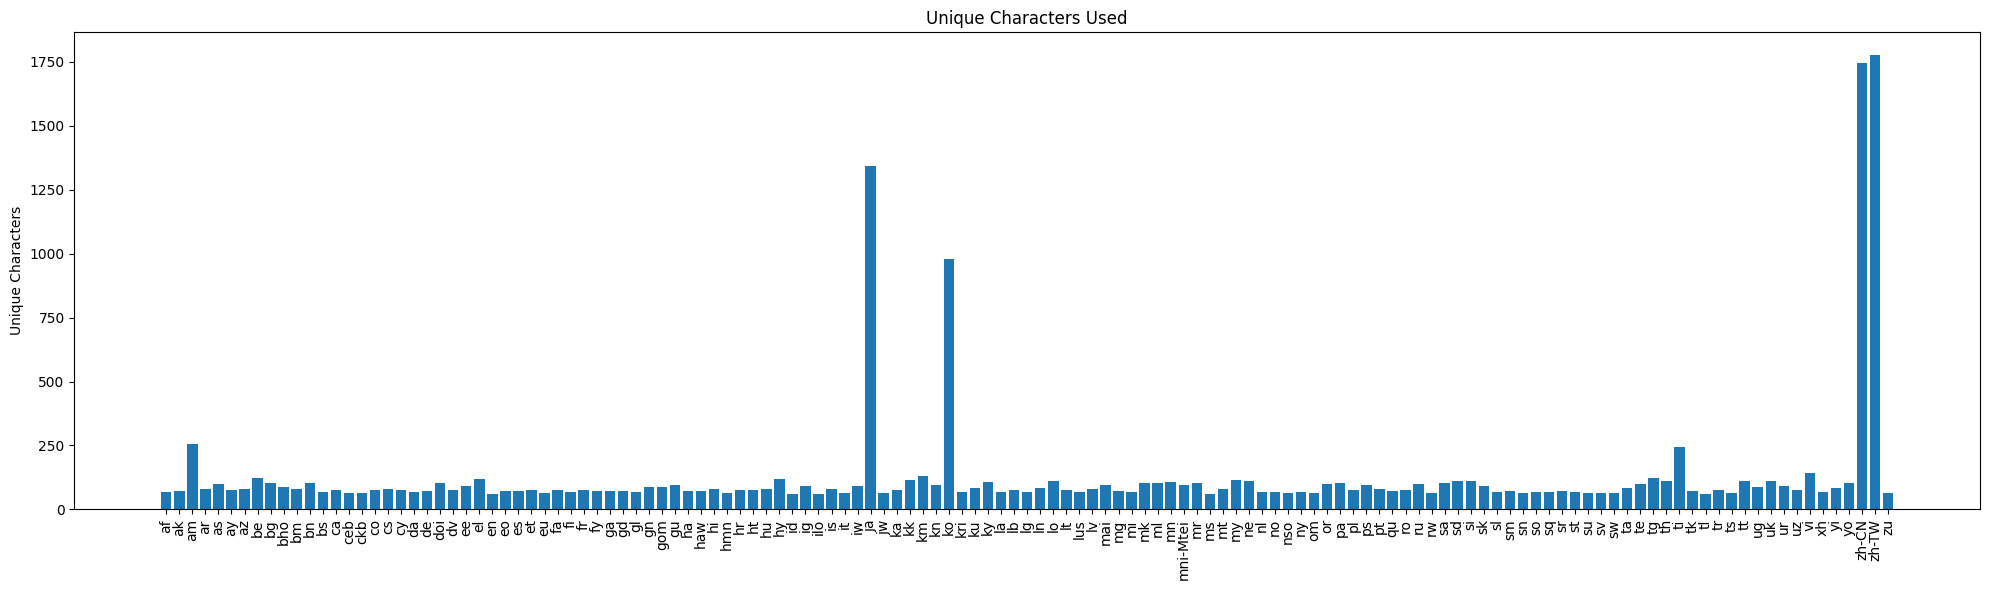

In [44]:
plt.figure(figsize=(20,6))

plt.bar(df["Language"], df["Unique Characters"])

plt.xticks(rotation=90)

plt.ylabel("Unique Characters")

plt.title("Unique Characters Used")

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(20,6))

plt.bar(df["Language"], df["Characters / Word"])

plt.xticks(rotation=90)

plt.ylabel("Characters per Word")

plt.title("Average Characters per Word")

plt.tight_layout()

plt.show()

In [46]:
from collections import Counter

for file in files[:5]:  # First 5 languages for testing

    language = file.replace(".txt", "")

    with open(os.path.join(TRANSLATED_DIR, file),
              encoding="utf-8") as f:

        text = f.read()

    chars = [c for c in text if not c.isspace()]

    freq = Counter(chars)

    print(f"\n{language}")
    print(freq.most_common(20))


af
[('e', 17567), ('a', 8391), ('n', 8357), ('i', 8114), ('o', 6479), ('s', 6123), ('t', 5942), ('d', 5479), ('r', 4960), ('g', 3850), ('h', 3625), ('k', 3606), ('l', 3418), ('y', 2761), ('m', 2537), ('u', 2275), ('w', 2064), ('v', 2061), ('.', 1830), ('p', 1331)]

ak
[('a', 17130), ('n', 12138), ('e', 8391), ('o', 7920), ('ɛ', 5570), ('i', 5145), ('s', 4779), ('m', 4560), ('ɔ', 4112), ('w', 3914), ('k', 3491), ('r', 3438), ('u', 3355), ('y', 2877), ('b', 2699), ('t', 2572), ('.', 2124), ('h', 2096), ('d', 2095), ('p', 1439)]

am
[('ን', 3724), ('እ', 2696), ('ው', 2548), ('በ', 2530), ('አ', 2184), ('ር', 1759), ('ለ', 1694), ('መ', 1676), ('ት', 1633), ('ም', 1614), ('ል', 1580), ('ነ', 1447), ('ስ', 1392), ('ይ', 1357), ('ና', 1334), ('።', 1316), ('የ', 1222), ('ላ', 1127), ('ደ', 1056), ('ተ', 1029)]

ar
[('ا', 11078), ('ل', 9925), ('ي', 5751), ('ن', 4985), ('م', 4633), ('و', 4034), ('ر', 3775), ('ك', 3345), ('ب', 2946), ('ع', 2921), ('ه', 2801), ('ت', 2777), ('أ', 2663), ('د', 2419), ('ق', 2154), (

In [47]:
import unicodedata

for file in files[:5]:

    language = file.replace(".txt","")

    with open(os.path.join(TRANSLATED_DIR,file),
              encoding="utf-8") as f:

        text = f.read()

    unique = sorted(set(text))

    print("\n", language)

    for c in unique[:20]:

        if c.strip():

            print(
                c,
                hex(ord(c)),
                unicodedata.name(c,"Unknown")
            )


 af
! 0x21 EXCLAMATION MARK
" 0x22 QUOTATION MARK
' 0x27 APOSTROPHE
, 0x2c COMMA
- 0x2d HYPHEN-MINUS
. 0x2e FULL STOP
: 0x3a COLON
; 0x3b SEMICOLON
? 0x3f QUESTION MARK
A 0x41 LATIN CAPITAL LETTER A
B 0x42 LATIN CAPITAL LETTER B
C 0x43 LATIN CAPITAL LETTER C
D 0x44 LATIN CAPITAL LETTER D
E 0x45 LATIN CAPITAL LETTER E
F 0x46 LATIN CAPITAL LETTER F
G 0x47 LATIN CAPITAL LETTER G
H 0x48 LATIN CAPITAL LETTER H
I 0x49 LATIN CAPITAL LETTER I

 ak
! 0x21 EXCLAMATION MARK
" 0x22 QUOTATION MARK
' 0x27 APOSTROPHE
, 0x2c COMMA
- 0x2d HYPHEN-MINUS
. 0x2e FULL STOP
: 0x3a COLON
; 0x3b SEMICOLON
? 0x3f QUESTION MARK
A 0x41 LATIN CAPITAL LETTER A
B 0x42 LATIN CAPITAL LETTER B
C 0x43 LATIN CAPITAL LETTER C
D 0x44 LATIN CAPITAL LETTER D
E 0x45 LATIN CAPITAL LETTER E
F 0x46 LATIN CAPITAL LETTER F
G 0x47 LATIN CAPITAL LETTER G
H 0x48 LATIN CAPITAL LETTER H
I 0x49 LATIN CAPITAL LETTER I

 am
! 0x21 EXCLAMATION MARK
" 0x22 QUOTATION MARK
, 0x2c COMMA
- 0x2d HYPHEN-MINUS
. 0x2e FULL STOP
1 0x31 DIGIT ONE
2 

In [50]:
import os

os.makedirs("character_analysis_v2", exist_ok=True)